In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
import sys
import os

sys.path.append(os.path.abspath(".."))

from geometry import *
from event_detector import *
from features_extractor import *
from tennis_metrics import *

CSV_FOLDER = Path(r"D:\desk\Results_Mediapipe\data_csv")

all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

print(f"There are {len(all_files)} files.")

There are 344 files.


In [2]:
all_files = sorted(list(CSV_FOLDER.glob('*.csv')))
platform = [f for f in all_files if 'platform' in f.name.lower()]
pinpoint = [f for f in all_files if 'pinpoint' in f.name.lower()]
platform_files = random.sample(platform, min(len(platform), 2))
pinpoint_files = random.sample(pinpoint, min(len(pinpoint), 2))

selected_files = platform_files + pinpoint_files

Analyzing 4 files for the Metric 1


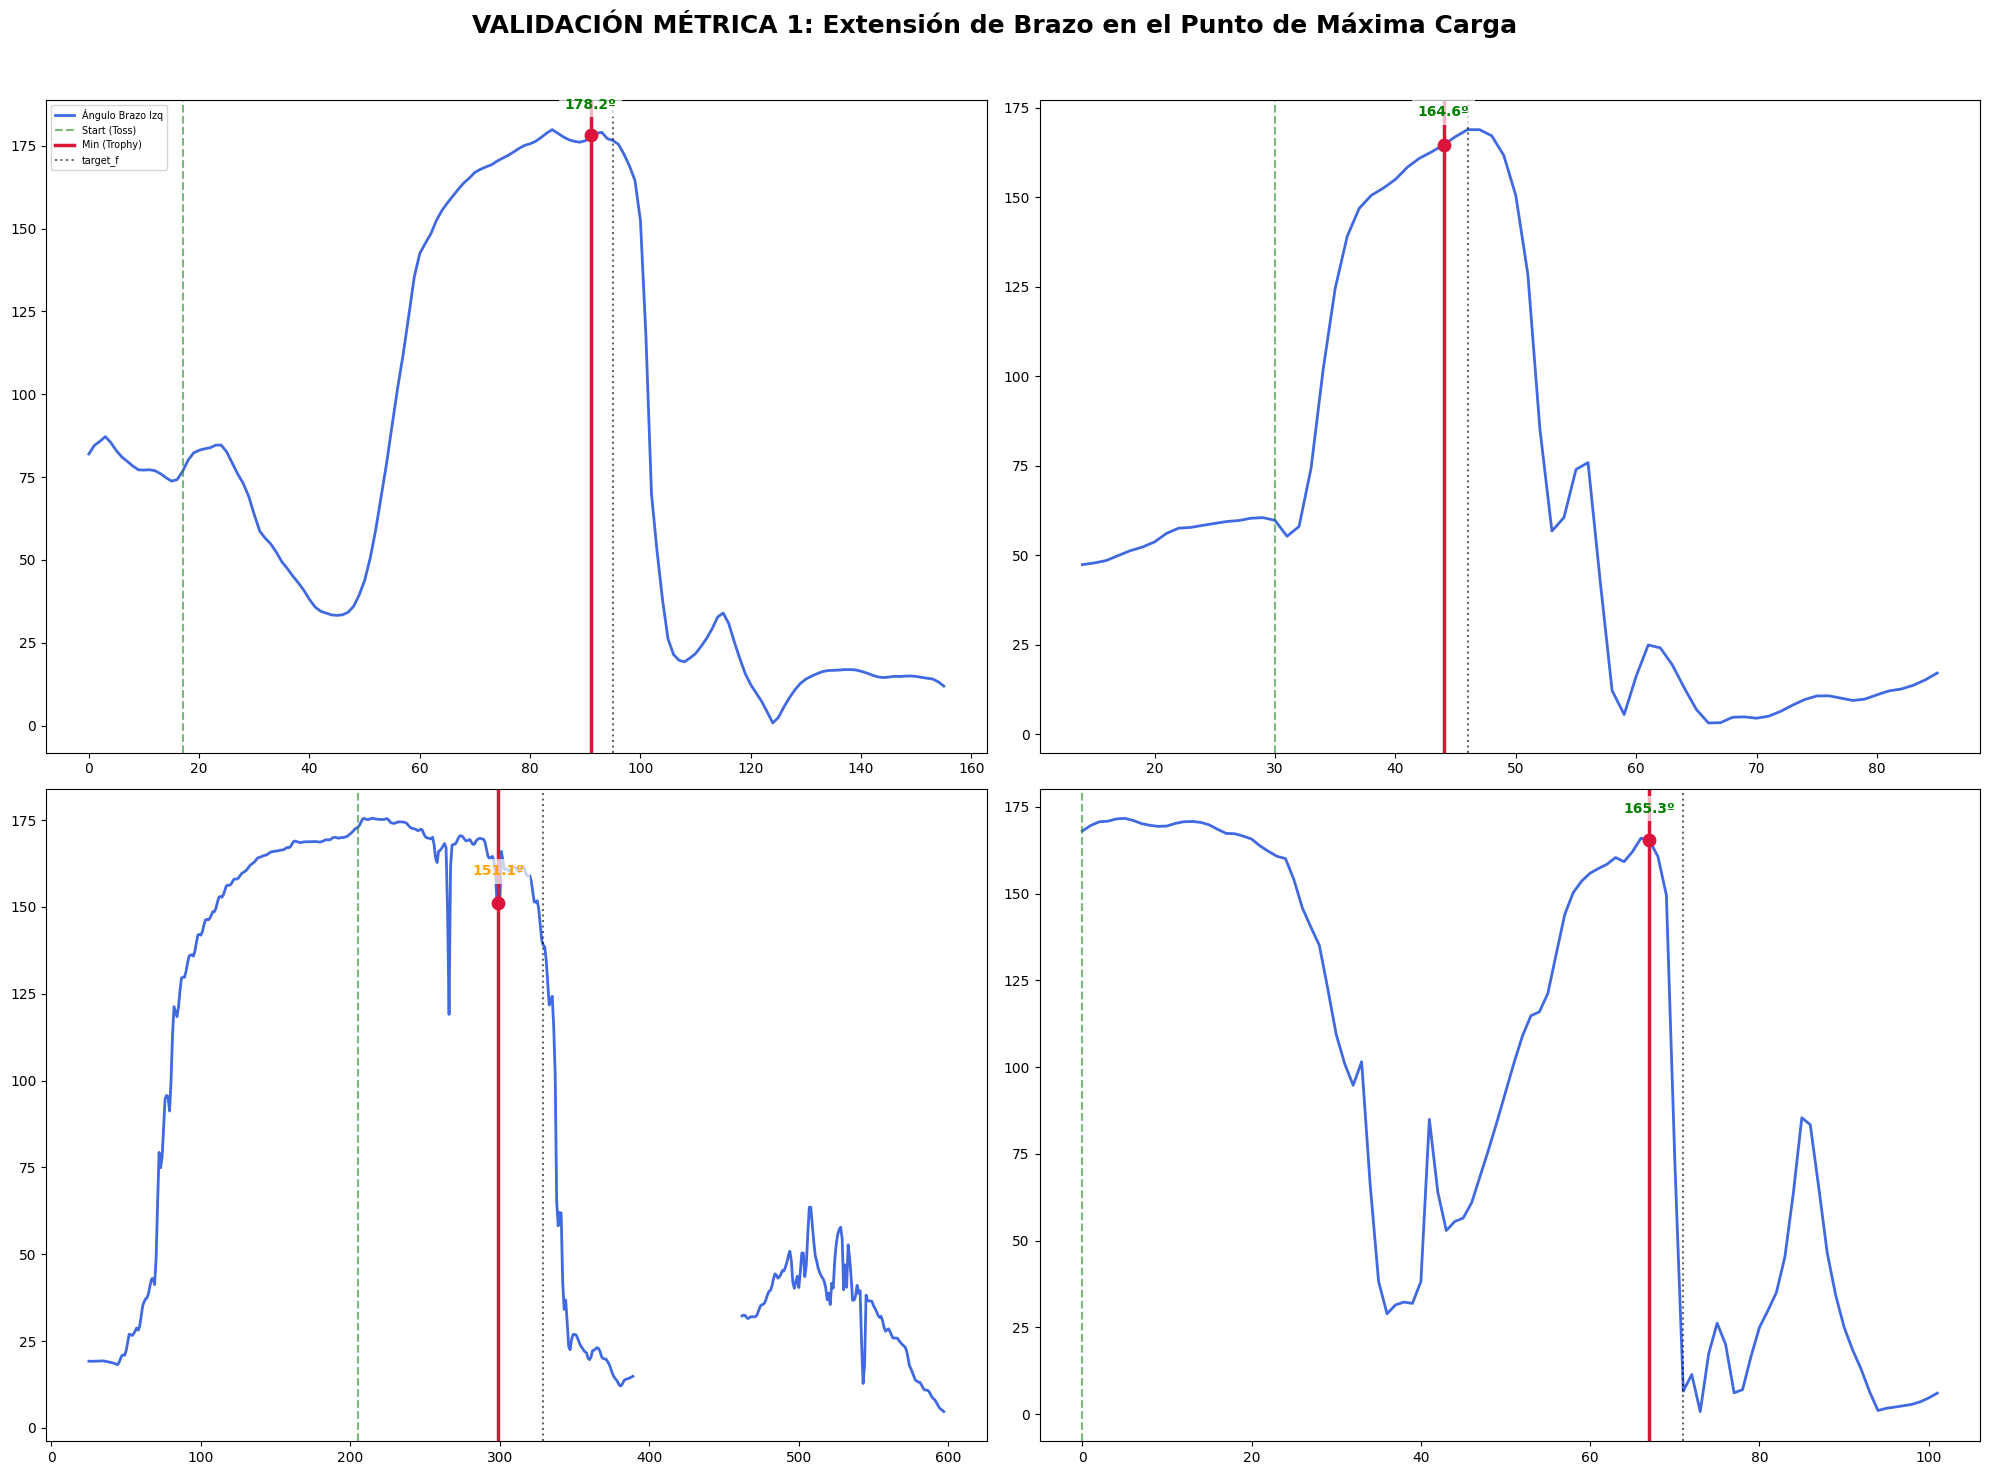

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

print(f"Analyzing {len(selected_files)} files for the Metric 1")

for i, file_path in enumerate(selected_files):
        if i >= 4: break        
        try:
            df = pd.read_csv(file_path).copy()
            
            start_f, min_f, max_f, target_f,_ = calculate_knee_frames(df)
            
            all_angles = get_non_dominant_arm_angles(df)
            
            ax = axes[i]
            ax.plot(all_angles, label='Ángulo Brazo Izq', color='royalblue', linewidth=2)

            ax.axvline(x=start_f, color='forestgreen', linestyle='--', alpha=0.6, label='Start (Toss)')
            ax.axvline(x=min_f, color='crimson', linestyle='-', linewidth=2.5, label='Min (Trophy)')
            ax.axvline(x=target_f, color='black', linestyle=':', alpha=0.6, label='target_f')
           
            metric1_angle = all_angles[min_f]
            ax.scatter(min_f, metric1_angle, color='crimson', s=80, zorder=5)
            
            color_txt = 'green' if metric1_angle >= 160 else ('orange' if metric1_angle >= 150 else 'red')
            ax.text(min_f, metric1_angle + 8, f"{metric1_angle:.1f}º", 
                    color=color_txt, fontweight='bold', ha='center', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))      
            
            if i == 0: 
                ax.legend(loc='upper left', fontsize='x-small')
                
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error:\n{file_path.stem}", ha='center')
            print(f"Error in {file_path.name}: {e}")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VALIDACIÓN MÉTRICA 1: Extensión de Brazo en el Punto de Máxima Carga", fontsize=18, fontweight='bold')

plt.savefig("validacion_metrica1_batch.png", dpi=150)
plt.show()

In [4]:
all_files = list(CSV_FOLDER.glob('*.csv'))

# Diccionario para contar los rangos
stats = {
    "Bajo (<160)": 0,
    "Transicion (160-165)": 0,
    "Optimo (165-180)": 0,
    "Excesivo (>180)": 0,
    "Errores": 0
}

print(f"Iniciando procesado de {len(all_files)} archivos...")

for f in all_files:
    try:
        df = pd.read_csv(f)
        
        # Obtenemos los frames clave
        # Asegúrate de que esta función no falle si el vídeo es malo
        _, min_f, _, target_f,_ = calculate_knee_frames(df)
        
        # Obtenemos los ángulos
        angles = get_non_dominant_arm_angles(df)
        val = angles[min_f]
        
        # Clasificamos el valor
        if val < 160:
            stats["Bajo (<160)"] += 1
        elif 160 <= val < 165:
            stats["Transicion (160-165)"] += 1
        elif 165 <= val <= 180:
            stats["Optimo (165-180)"] += 1
        elif val > 180:
            stats["Excesivo (>180)"] += 1
            
    except Exception as e:
        stats["Errores"] += 1
        continue

# Mostrar resultados
print("\n" + "="*30)
print("RESUMEN DE MÉTRICA 1 (Brazo-Cadera)")
print("="*30)
total_procesados = len(all_files) - stats["Errores"]

for rango, cuenta in stats.items():
    porcentaje = (cuenta / total_procesados * 100) if total_procesados > 0 else 0
    print(f"{rango:20} : {cuenta:4} vídeos ({porcentaje:5.1f}%)")
print("="*30)

Iniciando procesado de 344 archivos...

RESUMEN DE MÉTRICA 1 (Brazo-Cadera)
Bajo (<160)          :   42 vídeos ( 12.2%)
Transicion (160-165) :   23 vídeos (  6.7%)
Optimo (165-180)     :  272 vídeos ( 79.1%)
Excesivo (>180)      :    0 vídeos (  0.0%)
Errores              :    0 vídeos (  0.0%)


In [5]:
all_files = list(CSV_FOLDER.glob('*.csv'))

bajo_files = []

print(f"Buscando vídeos en el rango 'Bajo' (<160º)...")

for f in all_files:
    try:
        df = pd.read_csv(f)
        _, min_f, _, _, _ = calculate_knee_frames(df)
        angles = get_non_dominant_arm_angles(df)
        val = angles[min_f]
        
        if val < 160:
            # Guardamos el nombre y el valor para que sepas por cuánto falló
            bajo_files.append((f.name, val))
            
    except Exception:
        continue

# Ordenar por ángulo (de menor a mayor) para ver los más "cantosos" primero
bajo_files.sort(key=lambda x: x[1])

print("\n" + "="*50)
print(f"LISTA DE VÍDEOS BAJO EL UMBRAL (Total: {len(bajo_files)})")
print("="*50)
print(f"{'NOMBRE DEL ARCHIVO':<40} | {'ÁNGULO':<10}")
print("-"*50)

for name, angle in bajo_files:
    print(f"{name:<40} | {angle:>7.1f}º")

print("="*50)

Buscando vídeos en el rango 'Bajo' (<160º)...

LISTA DE VÍDEOS BAJO EL UMBRAL (Total: 42)
NOMBRE DEL ARCHIVO                       | ÁNGULO    
--------------------------------------------------
kick_pinpoint_239_pinpoint_kick_landmarks.csv |     2.3º
flat_pinpoint_133_landmarks.csv          |     8.5º
flat_platform_455_platform_flat_landmarks.csv |     8.6º
flat_platform_446_platform_flat_landmarks.csv |     9.7º
flat_pinpoint_132_landmarks.csv          |     9.8º
flat_pinpoint_220_pinpoint_flat _landmarks.csv |    11.9º
flat_platform_406_platform_flat_landmarks.csv |    12.5º
kick_pinpoint_212_pinpoint_kick_landmarks.csv |    13.1º
flat_platform_506_platform_flat_landmarks.csv |    15.7º
flat_platform_453_platform_flat_landmarks.csv |    16.1º
flat_platform_514_platform_flat_landmarks.csv |    16.1º
flat_pinpoint_261_pinpoint_flat_landmarks.csv |    16.2º
flat_platform_504_platform_flat_landmarks.csv |    17.8º
flat_platform_456_platform_flat_landmarks.csv |    18.0º
flat_pinpoint_24

# MÉTRICA 2: HIP DRIVE

In [6]:
# tennis_metrics.py

def calculate_hip_drive(df, start_f, min_f, hip_width):
    """
    Calcula el desplazamiento horizontal de la cadera hacia adelante.
    Un valor positivo indica que la cadera entra en la pista (Efecto Arco).
    """
    if hip_width == 0: return 0.0
    
    # 1. Calculamos el centro de la pelvis (promedio de X de ambas caderas)
    x_hip_start = (df.loc[start_f, 'LEFT_HIP_x'] + df.loc[start_f, 'RIGHT_HIP_x']) / 2
    x_hip_min = (df.loc[min_f, 'LEFT_HIP_x'] + df.loc[min_f, 'RIGHT_HIP_x']) / 2
    
    # 2. Desplazamiento (Para un diestro, entrar en pista suele ser aumentar X)
    # Nota: El signo depende de la orientación de la cámara
    displacement = x_hip_min - x_hip_start
    
    # 3. Normalizamos por el ancho de cadera para que sea una métrica universal
    return round(displacement / hip_width, 4)

In [7]:
def get_hip_center_series(df):
    # Calculamos el promedio X de ambas caderas para tener el centro de la pelvis
    return (df['LEFT_HIP_x'] + df['RIGHT_HIP_x']) / 2

Analizando 4 archivos para la Métrica 2: Hip Drive


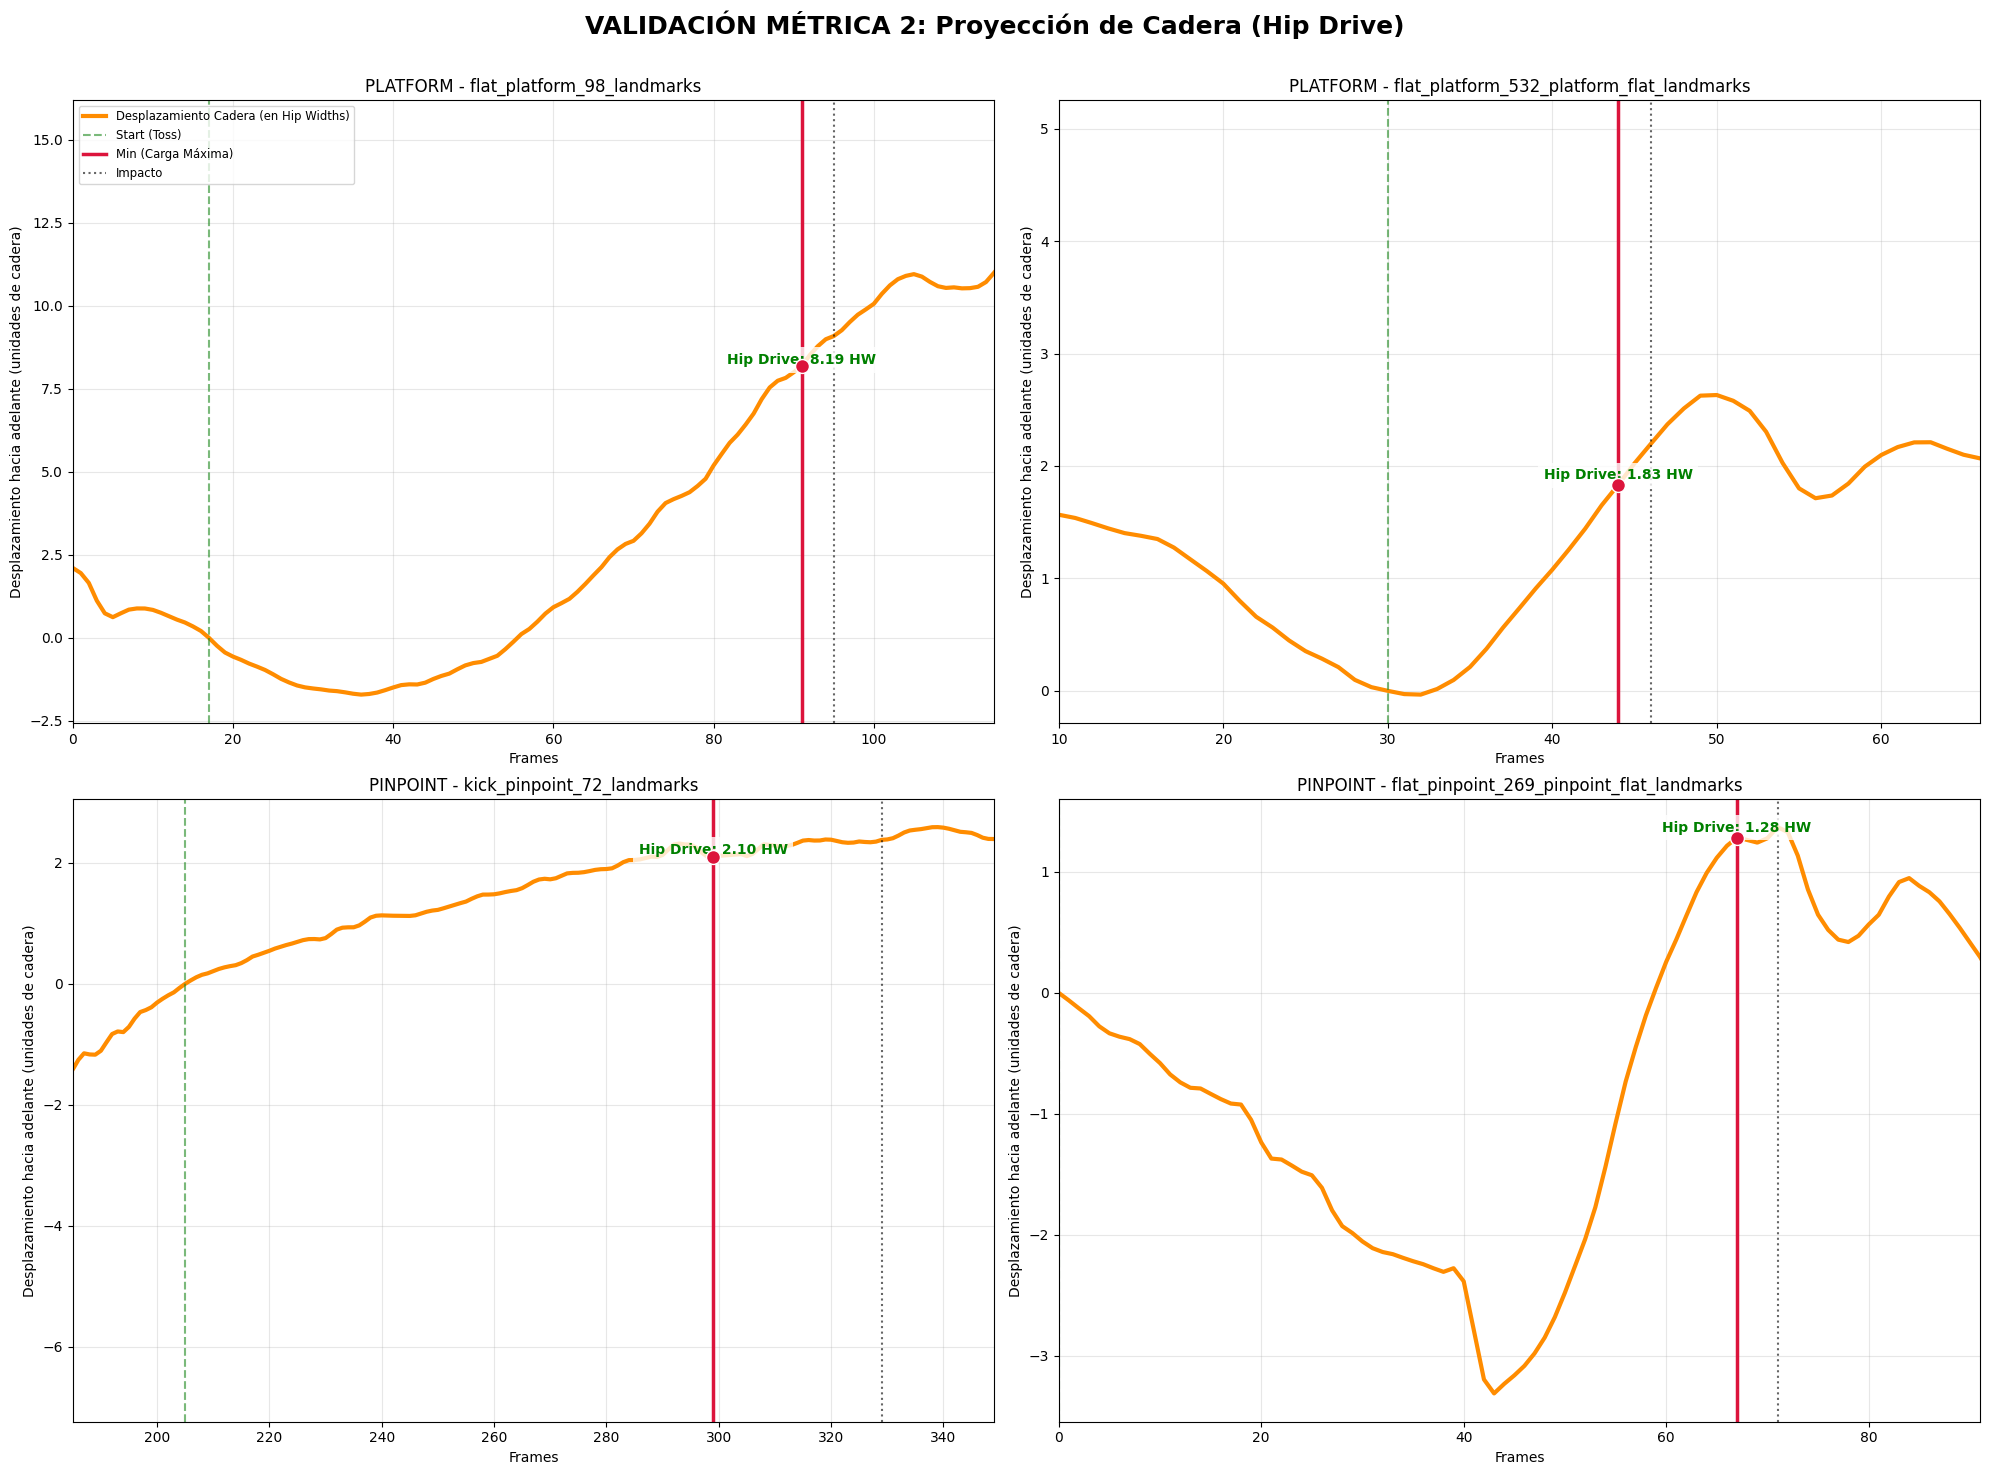

In [8]:
# 2. Configuración de la gráfica (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

print(f"Analizando {len(selected_files)} archivos para la Métrica 2: Hip Drive")

for i, file_path in enumerate(selected_files):
    if i >= 4: break        
    try:
        df = pd.read_csv(file_path).copy()
        
        # Obtener frames clave y ancho de cadera para normalizar
        start_f, min_f, max_f, target_f,_ = calculate_knee_frames(df) #
        hip_width = get_hip_width(df, start_f) #
        
        # Obtener la serie de posición horizontal de la cadera
        hip_x_series = get_hip_center_series(df)
        
        # Calculamos el desplazamiento relativo al inicio (en píxeles/coordenadas normalizadas)
        # Queremos ver cuánto se ha movido desde start_f
        displacement_series = (hip_x_series - hip_x_series[start_f])
        
        # Normalizamos por hip_width para obtener el "Hip Drive" real
        hip_drive_series = displacement_series / hip_width
        
        ax = axes[i]
        
        # Dibujamos la curva de desplazamiento
        ax.plot(hip_drive_series, label='Desplazamiento Cadera (en Hip Widths)', color='darkorange', linewidth=3)

        # Marcamos los hitos temporales
        ax.axvline(x=start_f, color='forestgreen', linestyle='--', alpha=0.6, label='Start (Toss)')
        ax.axvline(x=min_f, color='crimson', linestyle='-', linewidth=2.5, label='Min (Carga Máxima)')
        ax.axvline(x=target_f, color='black', linestyle=':', alpha=0.6, label='Impacto')
        
        # Resaltamos el valor de Hip Drive en el punto de carga
        val_critical = hip_drive_series[min_f]
        ax.scatter(min_f, val_critical, color='crimson', s=100, zorder=5, edgecolors='white')
        
        # Feedback visual basado en los rangos técnicos
        if val_critical >= 0.5: color_res = 'green'
        elif val_critical >= 0.2: color_res = 'orange'
        else: color_res = 'red'
        
        ax.text(min_f, val_critical + 0.05, f"Hip Drive: {val_critical:.2f} HW", 
                color=color_res, fontweight='bold', ha='center', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        # Estética
        stance_label = "PLATFORM" if 'platform' in file_path.name.lower() else "PINPOINT"
        ax.set_title(f"{stance_label} - {file_path.stem}", fontsize=12)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Desplazamiento hacia adelante (unidades de cadera)")
        ax.set_xlim(max(0, start_f - 20), target_f + 20)
        ax.grid(True, alpha=0.3)
        
        if i == 0: 
            ax.legend(loc='upper left', fontsize='small')
            
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Error:\n{file_path.name}\n{str(e)}", 
                     ha='center', va='center', color='red', wrap=True)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VALIDACIÓN MÉTRICA 2: Proyección de Cadera (Hip Drive)", fontsize=18, fontweight='bold')
plt.show()

In [9]:
clases = {
    "Negativo (Glitch/Error)": [],
    "Estándar/Controlado":     [],
    "Proyectado/Agresivo":     []
}

print(f"Processing {len(all_files)} files...")

for f in all_files:
    try:
        df = pd.read_csv(f)
        start_f, min_f, _, _, _ = calculate_knee_frames(df)

        hip_width = get_hip_width(df, start_f)
        if hip_width == 0: continue

        x_start   = (df.loc[start_f, 'LEFT_HIP_x'] + df.loc[start_f, 'RIGHT_HIP_x']) / 2
        x_min     = (df.loc[min_f,   'LEFT_HIP_x'] + df.loc[min_f,   'RIGHT_HIP_x']) / 2
        hip_drive = (x_min - x_start) / hip_width

        if hip_drive < 0:
            clases["Negativo (Glitch/Error)"].append((f.name, hip_drive))
        elif hip_drive <= 5:
            clases["Estándar/Controlado"].append((f.name, hip_drive))
        else:
            clases["Proyectado/Agresivo"].append((f.name, hip_drive))

    except Exception:
        print("error")

for clase, lista in clases.items():
    print(f"{clase}: {len(lista)} vídeos")

Processing 344 files...
Negativo (Glitch/Error): 23 vídeos
Estándar/Controlado: 229 vídeos
Proyectado/Agresivo: 92 vídeos


In [10]:
print("Clases erroneas: ")
print(f"{clases["Negativo (Glitch/Error)"]} \n")

Clases erroneas: 
[('flat_pinpoint_261_pinpoint_flat_landmarks.csv', -3.1671301437256125), ('flat_pinpoint_342_pinpoint_flat_landmarks.csv', -0.3434972866268475), ('flat_pinpoint_59_landmarks.csv', -2.970018910700716), ('flat_platform_358_platform_flat_landmarks.csv', -17.421692892404366), ('flat_platform_434_platform_flat_landmarks.csv', -1.4250290440946725), ('flat_platform_446_platform_flat_landmarks.csv', -1.5411154189874698), ('flat_platform_453_platform_flat_landmarks.csv', -0.3350109874433996), ('flat_platform_468_platform_flat_landmarks.csv', -0.18132873124841584), ('flat_platform_516_platform_flat_landmarks.csv', -0.3376081378448637), ('flat_platform_74_landmarks.csv', -0.4320048364031298), ('kick_pinpoint_212_pinpoint_kick_landmarks.csv', -0.8520746666523418), ('kick_pinpoint_274_pinpoint_kick_landmarks.csv', -0.36760436372357386), ('kick_pinpoint_276_pinpoint_kick_landmarks.csv', -0.2212118915454551), ('kick_pinpoint_278_pinpoint_kick_landmarks.csv', -1.1478655980243946), ('

In [11]:
# Iteramos sobre las categorías que nos interesan
for cat in ["Estándar/Controlado", "Proyectado/Agresivo"]:
    # Contamos basándonos en el nombre del archivo (que es el primer elemento de tu tupla)
    platform_n = sum(1 for nombre, _ in clases[cat] if "platform" in nombre.lower())
    pinpoint_n = sum(1 for nombre, _ in clases[cat] if "pinpoint" in nombre.lower())
    
    print(f"### {cat} ###")
    print(f"  * Platform: {platform_n}")
    print(f"  * Pinpoint: {pinpoint_n}")
    print("-" * 30)

### Estándar/Controlado ###
  * Platform: 154
  * Pinpoint: 80
------------------------------
### Proyectado/Agresivo ###
  * Platform: 45
  * Pinpoint: 47
------------------------------


In [12]:
# Iteramos sobre las categorías de interés
for cat in ["Estándar/Controlado", "Proyectado/Agresivo"]:
    # Contamos basándonos en las palabras clave del efecto en el nombre del archivo
    flat_n  = sum(1 for nombre, _ in clases[cat] if "flat" in nombre.lower())
    kick_n  = sum(1 for nombre, _ in clases[cat] if "kick" in nombre.lower())
    slice_n = sum(1 for nombre, _ in clases[cat] if "slice" in nombre.lower())
    
    print(f"### {cat} ###")
    print(f"  * Flat:  {flat_n}")
    print(f"  * Kick:  {kick_n}")
    print(f"  * Slice: {slice_n}")
    print("-" * 30)

### Estándar/Controlado ###
  * Flat:  128
  * Kick:  38
  * Slice: 63
------------------------------
### Proyectado/Agresivo ###
  * Flat:  51
  * Kick:  22
  * Slice: 19
------------------------------


In [13]:
print("Clases erroneas: ")
print(f"{clases["Proyectado/Agresivo"]} \n")

Clases erroneas: 
[('flat_pinpoint_126_landmarks.csv', 13.813892637301938), ('flat_pinpoint_133_landmarks.csv', 15.172955013937749), ('flat_pinpoint_137_landmarks.csv', 18.482630670520482), ('flat_pinpoint_138_landmarks.csv', 14.090559180176607), ('flat_pinpoint_141_landmarks.csv', 5.939502144317162), ('flat_pinpoint_203_pinpoint_flat_landmarks.csv', 6.0772068241668835), ('flat_pinpoint_204_pinpoint_flat_landmarks.csv', 10.421712975471188), ('flat_pinpoint_226_pinpoint_flat_landmarks.csv', 13.637037116214453), ('flat_pinpoint_234_pinpoint_flat_landmarks.csv', 5.368100881965101), ('flat_pinpoint_236_pinpoint_flat_landmarks.csv', 5.945308499231769), ('flat_pinpoint_240_pinpoint_flat_landmarks.csv', 25.702715275730565), ('flat_pinpoint_264_pinpoint_flat_landmarks.csv', 10.698733249590765), ('flat_pinpoint_266_pinpoint_flat_landmarks.csv', 15.388219408504112), ('flat_pinpoint_267_pinpoint_flat_landmarks.csv', 13.000660304014378), ('flat_pinpoint_279_pinpoint_flat_landmarks.csv', 9.64248022